In [44]:
import numpy as np
import umap
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_1.npz"
EMBEDDING_MODEL_PATH = "mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model.fit(_embeddings)

d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [45]:
# Generate and evaluate multiple tracks plus mutated variants
import requests
import random
import copy

randomizer = random.Random(100)
num_tracks = 10
seed_candidates = randomizer.sample(range(1, 10000), num_tracks)

def generate_track(seed, randomizer):
    response = requests.post(
        "http://localhost:4242/generate",
        json={
            "id": seed,
            "mode": "voronoi",
            "trackSize": randomizer.randint(4, 10),
            "rngMode": 0,
        },
        timeout=60,
    )

    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    sol = response.json()
    sol["rngMode"] = 1
    return sol

def mutate_track(sol_in, intensity, randomizer):
    # deep copy sol
    sol = copy.deepcopy(sol_in)

    seed = sol["id"]
    response = requests.post(
                    f"http://localhost:4242/mutate",
                    json={
                        "individual": sol,
                        "intensityMutation": intensity, # Constant mutation intensity
                        "genetic_seed": seed
                    },
                    timeout=60
                )
    if not response.ok:
                    raise Exception(f"API error {response.status_code}: {response.text}")
    mutated = response.json().get("mutated", {})
    print("Mutated track keys:", mutated.keys())
    
    # Assign a unique, iteration-based ID for tracking
    sol["dataSet"] = mutated["dataSet"]
    # mutated["mode"] = sol.get("mode", "voronoi")
    sol["selectedCells"] = mutated["selectedCells"]
    return sol       

def eval_track(sol, get_traces=False):
    payload = dict(sol)
    if get_traces:
        payload["getTraces"] = True
    response = requests.post(
        "http://localhost:4242/evaluate",
        json=payload,
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    fit = r_json.get("fitness", {}) or {}
    trace_data = {}
    if get_traces:
        trace_data = {
            "speed_trace": fit.get("speed_trace", None),
            "steer_trace": fit.get("steer_trace", None),
            "brake_trace": fit.get("brake_trace", None),
            "accel_trace": fit.get("accel_trace", None),
            "border_dist_trace": fit.get("border_dist_trace", None),
        }
    return fit, trace_data

def reconstruct_track(sol):
    response = requests.post(
        "http://localhost:4242/reconstruct",
        json={
            "mode": sol.get("mode", "voronoi"),
            "seed": sol["id"],
            "dataSet": sol["dataSet"],
            "selectedCells": sol["selectedCells"],
            "trackSize": sol["trackSize"]
        },
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    return r_json.get("track", None)

seeds = seed_candidates[:3]
intensities = [2, 10, 50, 70, 100, 500]

results_by_seed = {}
for seed in seeds:
    try:
        sol = generate_track(seed, randomizer)
    except Exception as exc:
        print(f"Seed {seed}: generate failed -> {exc}")
        continue
    print(f"Generated track keys for seed {seed}:", sol.keys())

    try:
        original_fit, original_traces = eval_track(sol, get_traces=True)
        original_embedding_data = original_fit.get("embedding_data", [])
    except Exception as exc:
        print(f"Seed {seed}: eval failed -> {exc}")
        continue

    try:
        original_track = reconstruct_track(sol)
    except Exception as exc:
        print(f"Seed {seed}: reconstruct failed -> {exc}")
        original_track = None

    mutated_embedding_data_by_intensity = {}
    mutated_traces_by_intensity = {}
    mutated_tracks_by_intensity = {}
    for intensity in intensities:
        try:
            mutated = mutate_track(sol, intensity=intensity, randomizer=randomizer)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: mutate failed -> {exc}")
            continue
        try:
            mutated_fit, mutated_traces = eval_track(mutated, get_traces=True)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: eval failed -> {exc}")
            continue
        mutated_embedding_data_by_intensity[intensity] = mutated_fit.get("embedding_data", [])
        mutated_traces_by_intensity[intensity] = mutated_traces
        try:
            mutated_tracks_by_intensity[intensity] = reconstruct_track(mutated)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: reconstruct failed -> {exc}")
            mutated_tracks_by_intensity[intensity] = None

    results_by_seed[seed] = {
        "intensities": intensities,
        "original_embedding_data": original_embedding_data,
        "original_traces": original_traces,
        "original_track": original_track,
        "mutated_embedding_data_by_intensity": mutated_embedding_data_by_intensity,
        "mutated_traces_by_intensity": mutated_traces_by_intensity,
        "mutated_tracks_by_intensity": mutated_tracks_by_intensity,
    }

Generated track keys for seed 2387: dict_keys(['id', 'mode', 'dataSet', 'selectedCells', 'trackSize', 'splineVector', 'rngMode'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Generated track keys for seed 7529: dict_keys(['id', 'mode', 'dataSet', 'selectedCells', 'trackSize', 'splineVector', 'rngMode'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Generated track keys

Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth...
Model loaded with latent_dim=32


C:\Users\milob\AppData\Local\Temp\ipykernel_31232\931951594.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


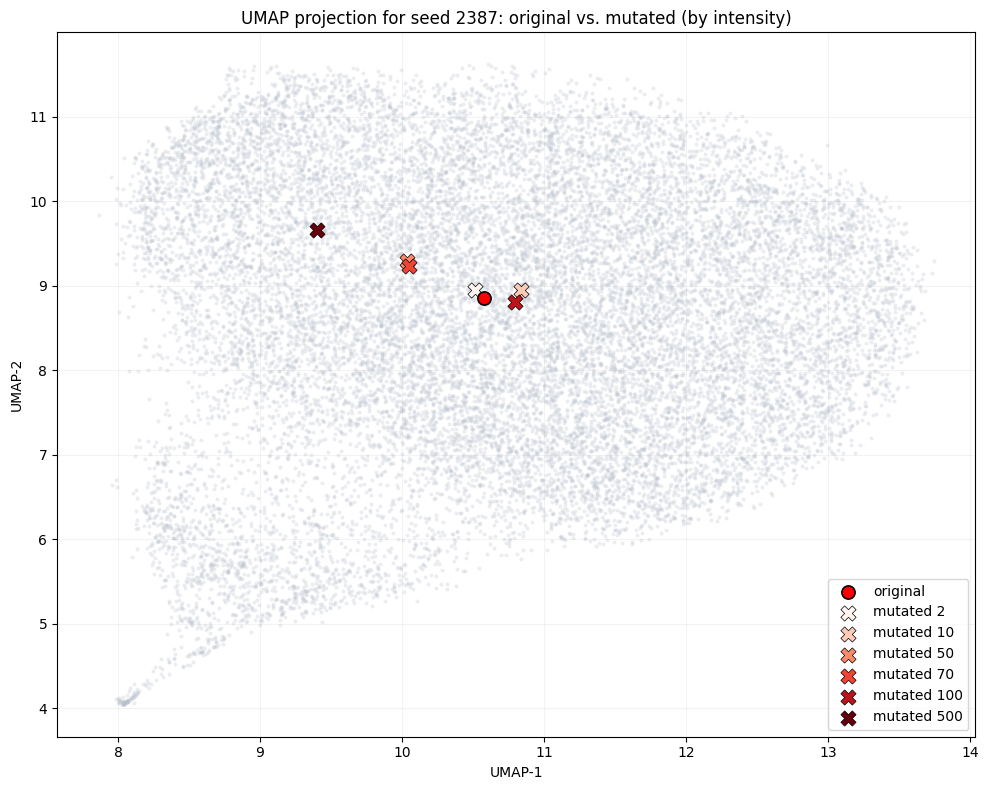

Original_embedding: [[ 2.46755779e-04 -1.78956747e-01 -3.70043010e-01 -1.17000639e+00
  -2.27418542e-01 -1.87077284e-01  4.12561417e-01 -1.13435793e+00
   4.61357921e-01 -6.71899378e-01 -3.68182123e-01  2.83032864e-01
   1.10920645e-01  4.47541550e-02 -4.56226498e-01  2.89245218e-01
  -4.77093250e-01  4.45742533e-03 -6.59849942e-01  5.33837438e-01
  -1.64797351e-01  3.79526615e-01 -8.68711948e-01 -4.51315105e-01
   1.60889968e-01 -9.83192697e-02 -5.21261506e-02 -8.63129571e-02
  -6.58993572e-02 -2.96949029e-01 -7.53632262e-02 -7.71427333e-01]]
Mutated_embedding_2: [[-0.01827032 -0.14910638 -0.34170535 -1.2407298  -0.24207038 -0.17027494
   0.41478175 -1.2307051   0.46785256 -0.78961784 -0.41515547  0.25998756
   0.11292852  0.04547501 -0.48201445  0.27106127 -0.49683976  0.00925828
  -0.68665177  0.6301072  -0.15170796  0.36761498 -0.8464059  -0.45833588
   0.16064431 -0.04879222 -0.05530123 -0.14848371 -0.06172894 -0.32186317
  -0.08939148 -0.80594164]]
Mutated_embedding_10: [[-0.0765

C:\Users\milob\AppData\Local\Temp\ipykernel_31232\931951594.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


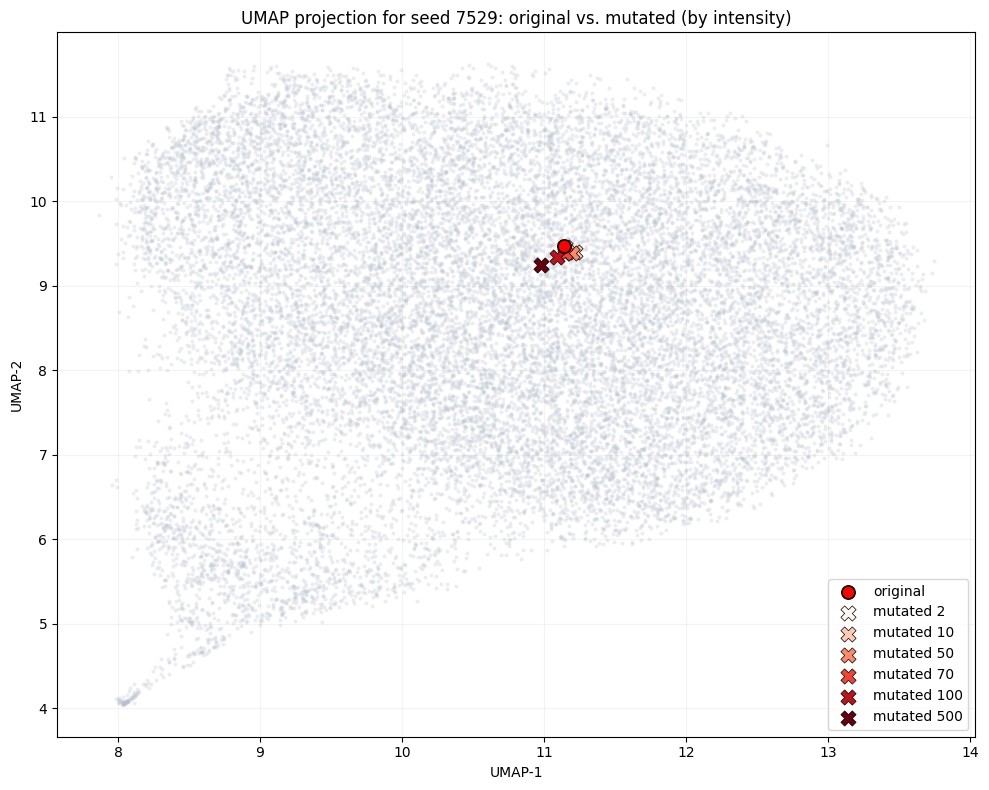

Original_embedding: [[-1.0522426e-01 -5.6337082e-01 -1.0214810e+00 -3.1522036e-02
   3.9780140e-04 -5.5052781e-01  1.0860115e-01  5.9488732e-01
   2.2471194e-01  2.0767138e+00  8.1116611e-01  6.2932664e-01
   3.0891204e-01 -1.4064424e-02 -2.0802900e-01  8.8263702e-01
   8.6197639e-01 -4.5079660e-01 -4.9086922e-01 -1.3969839e+00
  -9.6661729e-01  7.5300080e-01 -1.2242879e+00 -4.5292932e-01
   2.1712269e-01 -6.3694251e-01 -1.3421513e-01  1.1026288e+00
   2.6068667e-01  4.8694539e-01  1.4646697e-01 -5.3900272e-01]]
Mutated_embedding_2: [[-0.07308502 -0.50722134 -0.88221836 -0.2598517  -0.05018342 -0.47177657
   0.17073244  0.20112298  0.2705566   1.5972575   0.71150875  0.5005879
   0.29102272  0.03995854 -0.2610955   0.7701754   0.68277466 -0.33543158
  -0.5156074  -1.0667303  -0.87152547  0.7482219  -1.1810384  -0.5037375
   0.22520287 -0.5314226  -0.14889033  0.87489814  0.21985127  0.37671506
   0.12885702 -0.5763541 ]]
Mutated_embedding_10: [[-0.07831592 -0.4213314  -0.67079306 -0.09

C:\Users\milob\AppData\Local\Temp\ipykernel_31232\931951594.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


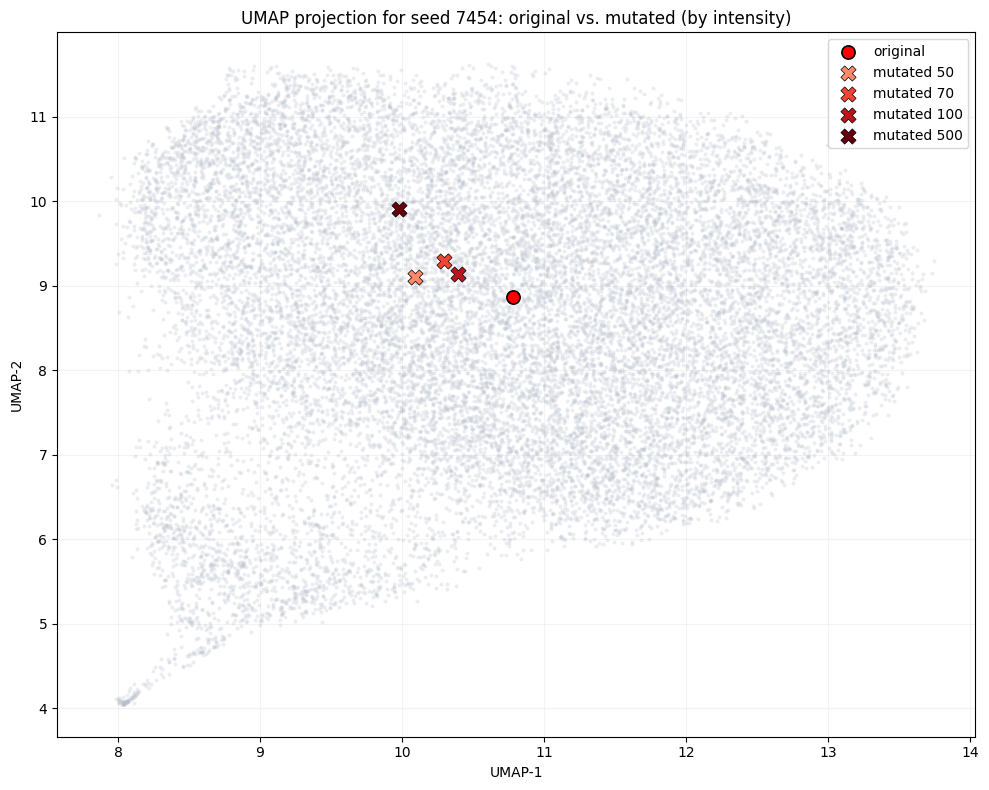

Original_embedding: [[-0.02511752 -0.15701091 -0.5751903  -0.84882385 -0.13643038 -0.21124235
   0.3549649  -0.56842947  0.28544018  0.19258802 -0.02117778  0.34618422
   0.10466579  0.00499112 -0.37609634  0.37112254 -0.15027402 -0.06773798
  -0.5341397  -0.02683035 -0.28812867  0.55336845 -1.0152583  -0.42409205
   0.09339316 -0.18432936 -0.03806136  0.26450014 -0.06059847 -0.18354978
   0.16696632 -0.65592045]]
Mutated_embedding_2: None
Mutated_embedding_10: None
Mutated_embedding_50: [[-0.07783527  0.04168361  0.19376007 -0.66729426 -0.25862777 -0.10625032
   0.23637217 -0.90175116  0.20681058 -0.466765   -0.27693725  0.332684
   0.1226866   0.05037171 -0.24845979  0.23321012  0.05097858 -0.06999443
  -0.3420871   0.30327627 -0.35223562  0.31268585 -0.603266   -0.31519967
   0.18171258 -0.04896221 -0.07825075 -0.23721294 -0.03088127 -0.56224036
   0.1863355  -0.38923463]]
Mutated_embedding_70: [[ 0.04346751  0.04568469 -0.01597556 -0.489416    0.0168637  -0.11907777
   0.15658069 -

In [46]:
import matplotlib.pyplot as plt
from mapelite.evaluator import EvaluatorMetrics

evaluator = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)

def _convert_metrics_to_embedding(metrics_data):
    """Convert raw metric data to VAE embedding."""
    if not metrics_data or len(metrics_data) == 0:
        return None
    metrics_array = np.array(metrics_data)
    embedding = evaluator.measure_from_metrics(metrics_array)
    return np.asarray(embedding).reshape(1, -1)

for seed, payload in results_by_seed.items():
    intensities = payload["intensities"]
    original_embedding = _convert_metrics_to_embedding(payload["original_embedding_data"])

    mutated_embeddings_by_intensity = {
        intensity: _convert_metrics_to_embedding(metrics)
        for intensity, metrics in payload["mutated_embedding_data_by_intensity"].items()
    }

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        umap_model.embedding_[:, 0],
        umap_model.embedding_[:, 1],
        s=8,
        c="#b8c0cc",
        alpha=0.28,
        linewidths=0,
        label="_embeddings background",
    )

    legend_handles = []
    legend_labels = []
    if original_embedding is not None:
        original_umap = umap_model.transform(original_embedding)
        original_handle = ax.scatter(
            original_umap[:, 0],
            original_umap[:, 1],
            s=90,
            c="#ff0000",
            edgecolors="black",
            linewidths=1.2,
            label="original",
            zorder=4,
        )
        legend_handles.append(original_handle)
        legend_labels.append("original")

    cmap = plt.cm.get_cmap("Reds", len(intensities))
    mutated_handles = {}
    for idx, intensity in enumerate(intensities):
        embedding = mutated_embeddings_by_intensity.get(intensity)
        if embedding is None:
            continue
        color = cmap(idx)
        mutated_umap = umap_model.transform(embedding)
        mutated_handles[intensity] = ax.scatter(
            mutated_umap[:, 0],
            mutated_umap[:, 1],
            s=120,
            c=[color],
            marker="X",
            edgecolors="black",
            linewidths=0.5,
            label=f"mutated {intensity}",
            zorder=3,
        )

    for intensity in intensities:
        handle = mutated_handles.get(intensity)
        if handle is None:
            continue
        legend_handles.append(handle)
        legend_labels.append(f"mutated {intensity}")

    ax.set_title(f"UMAP projection for seed {seed}: original vs. mutated (by intensity)")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(legend_handles, legend_labels, frameon=True)
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

    print("Original_embedding:", original_embedding)
    for intensity in intensities:
        print(f"Mutated_embedding_{intensity}:", mutated_embeddings_by_intensity.get(intensity))

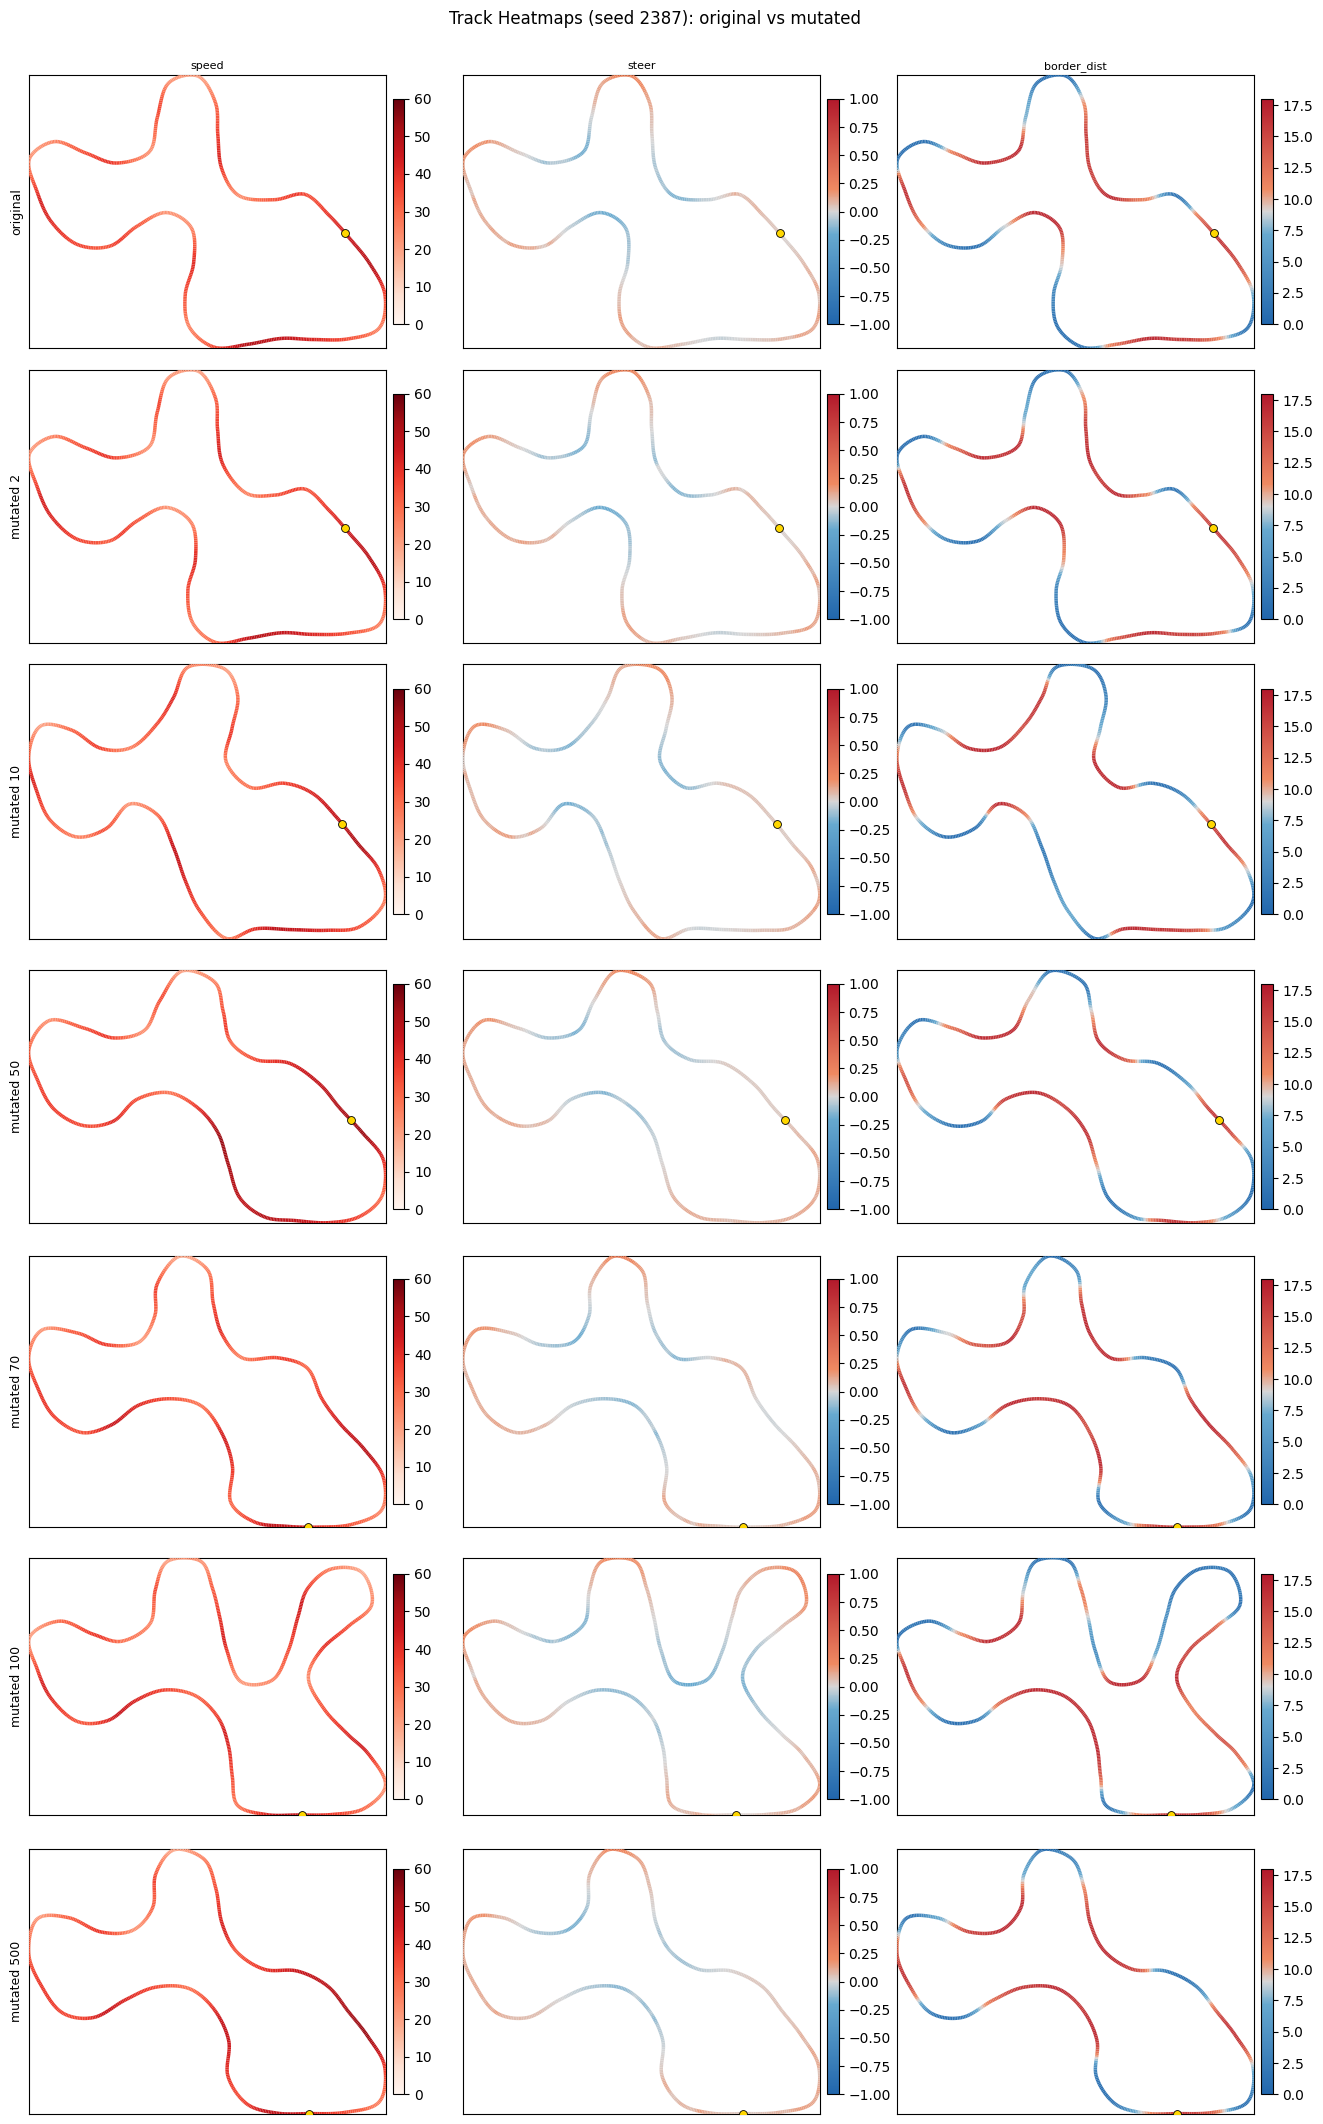

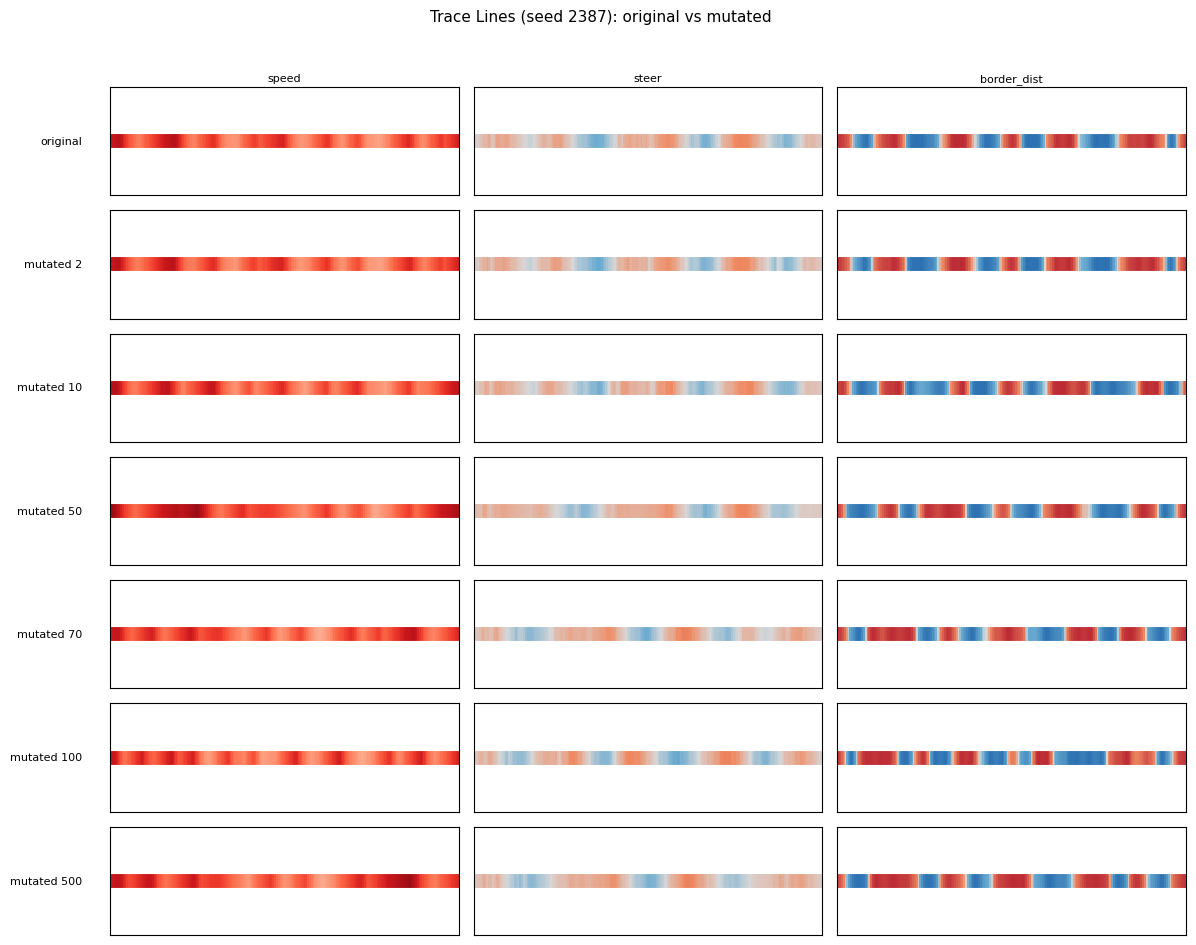

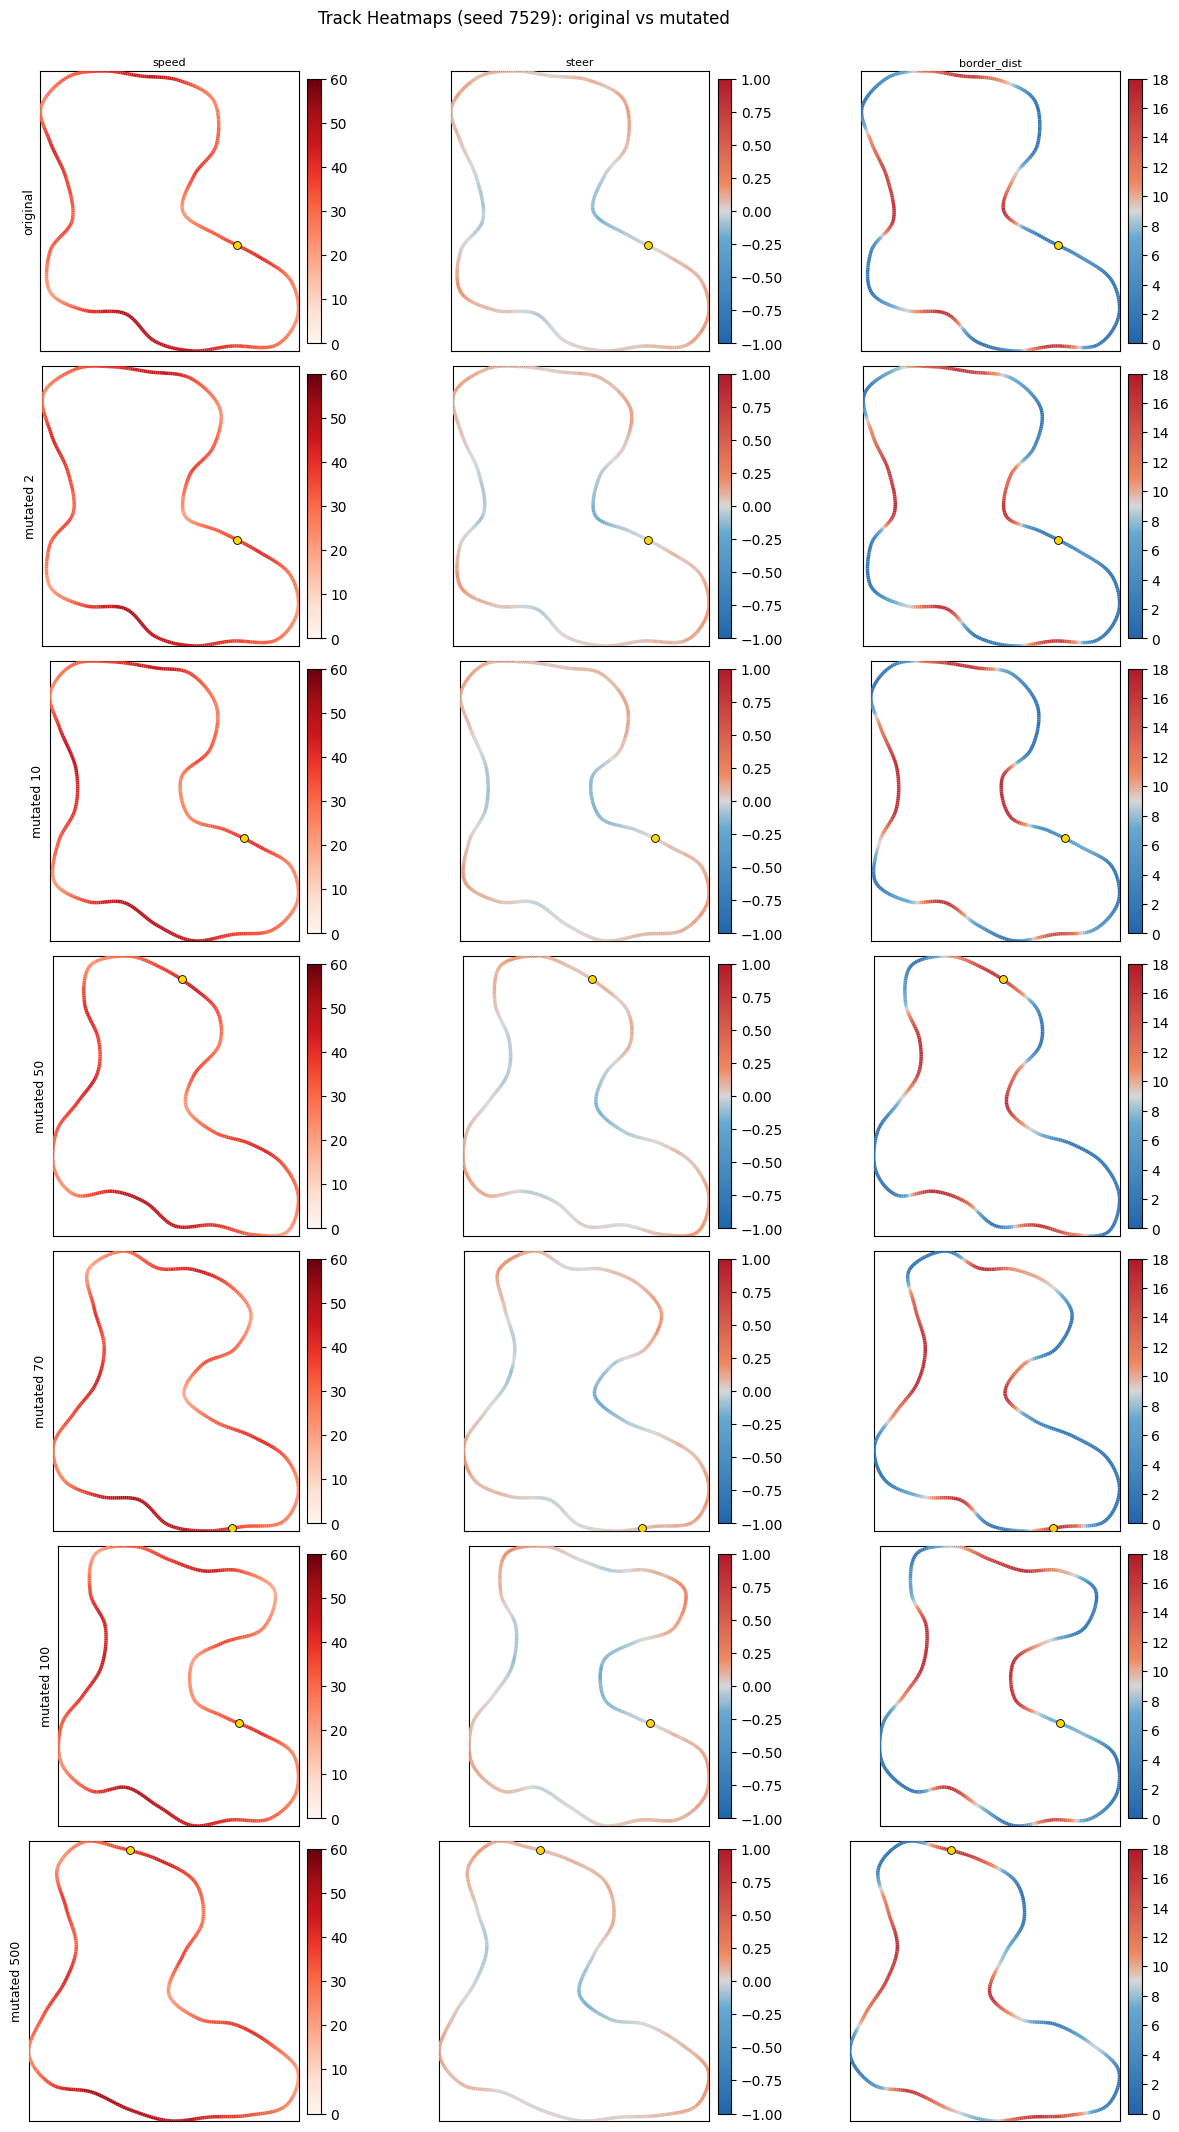

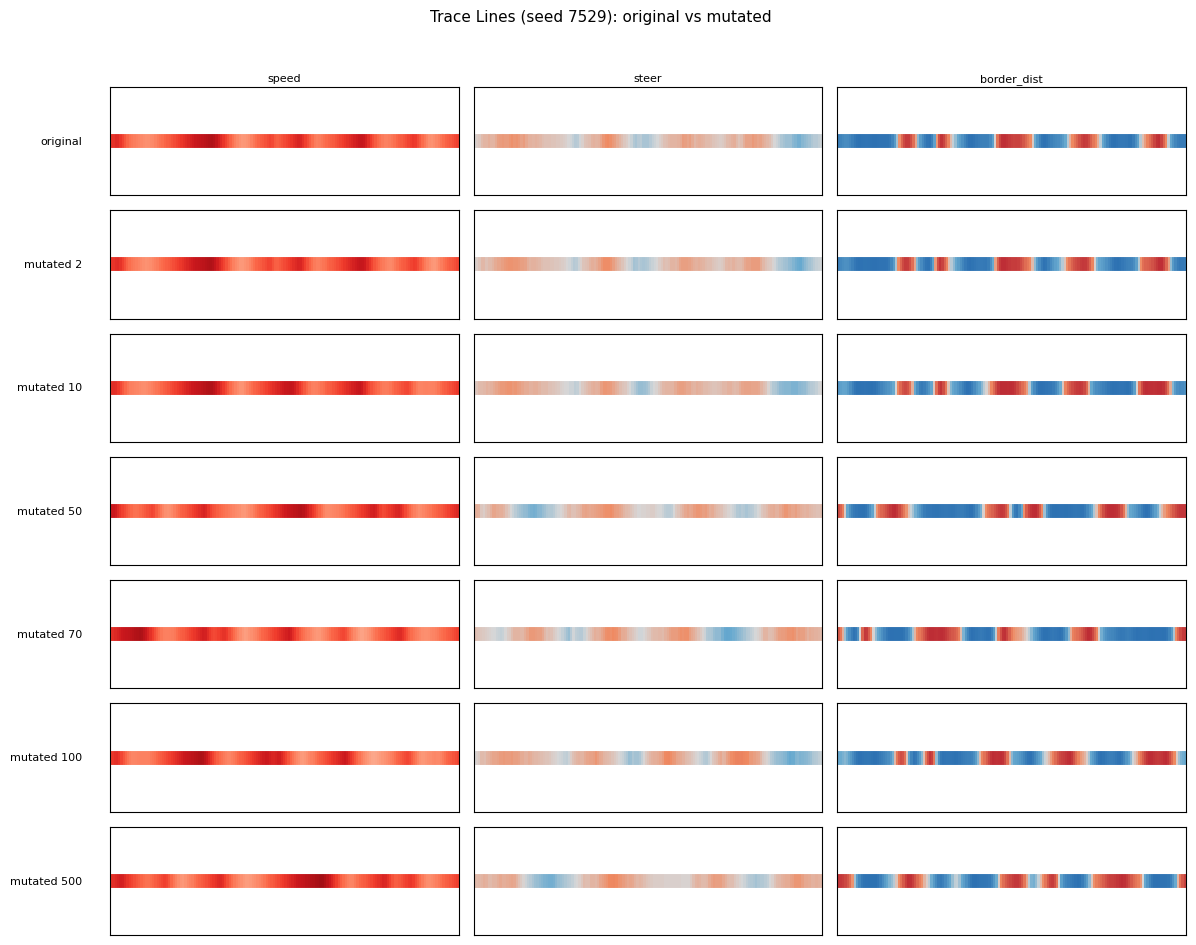

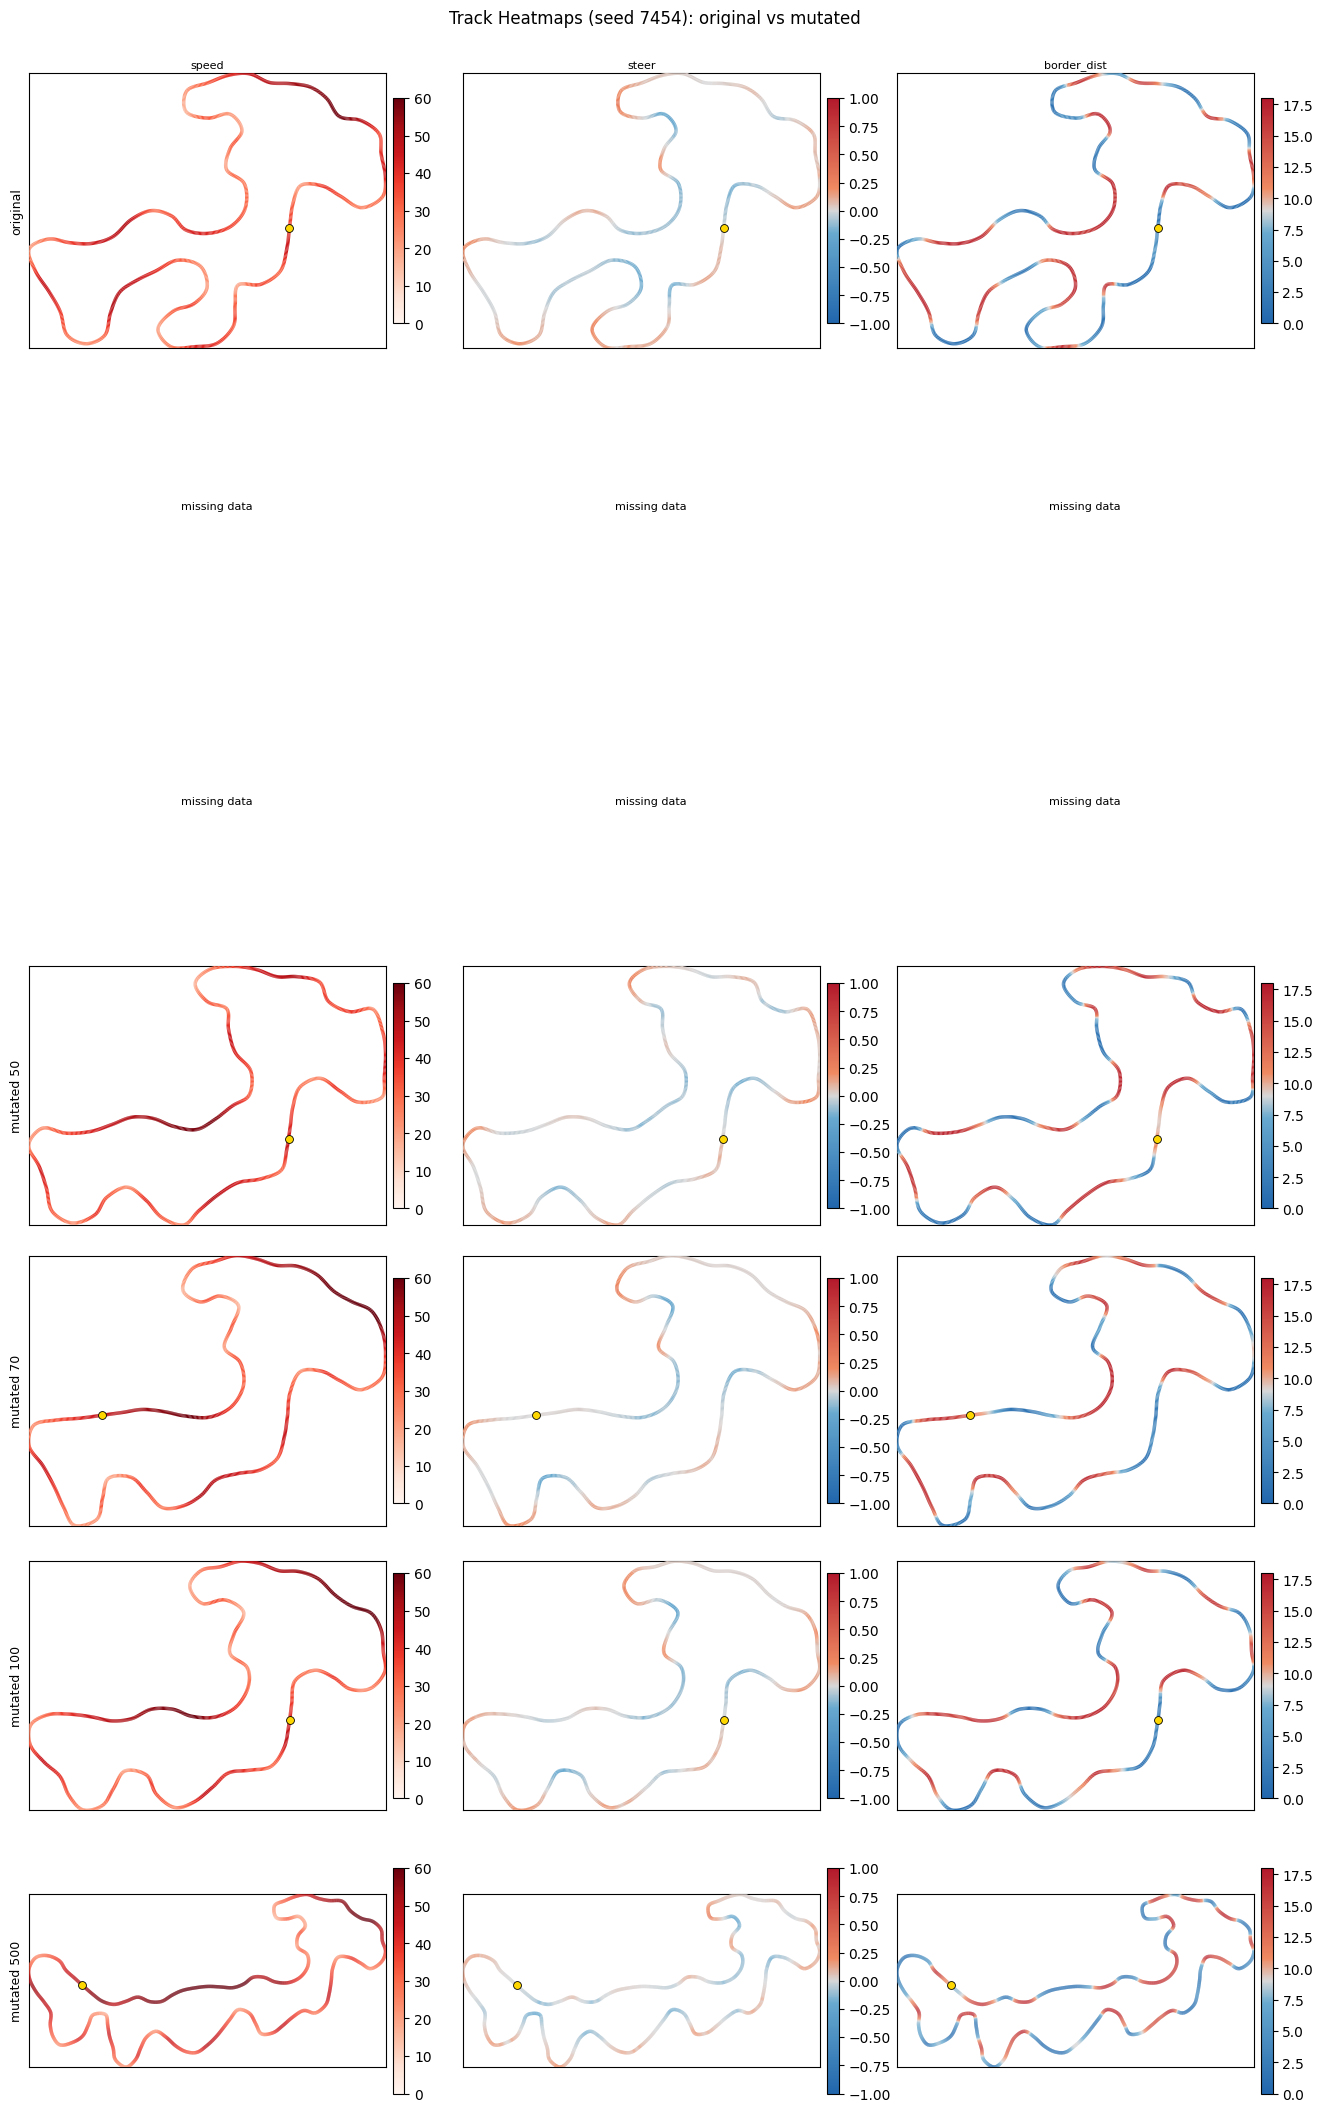

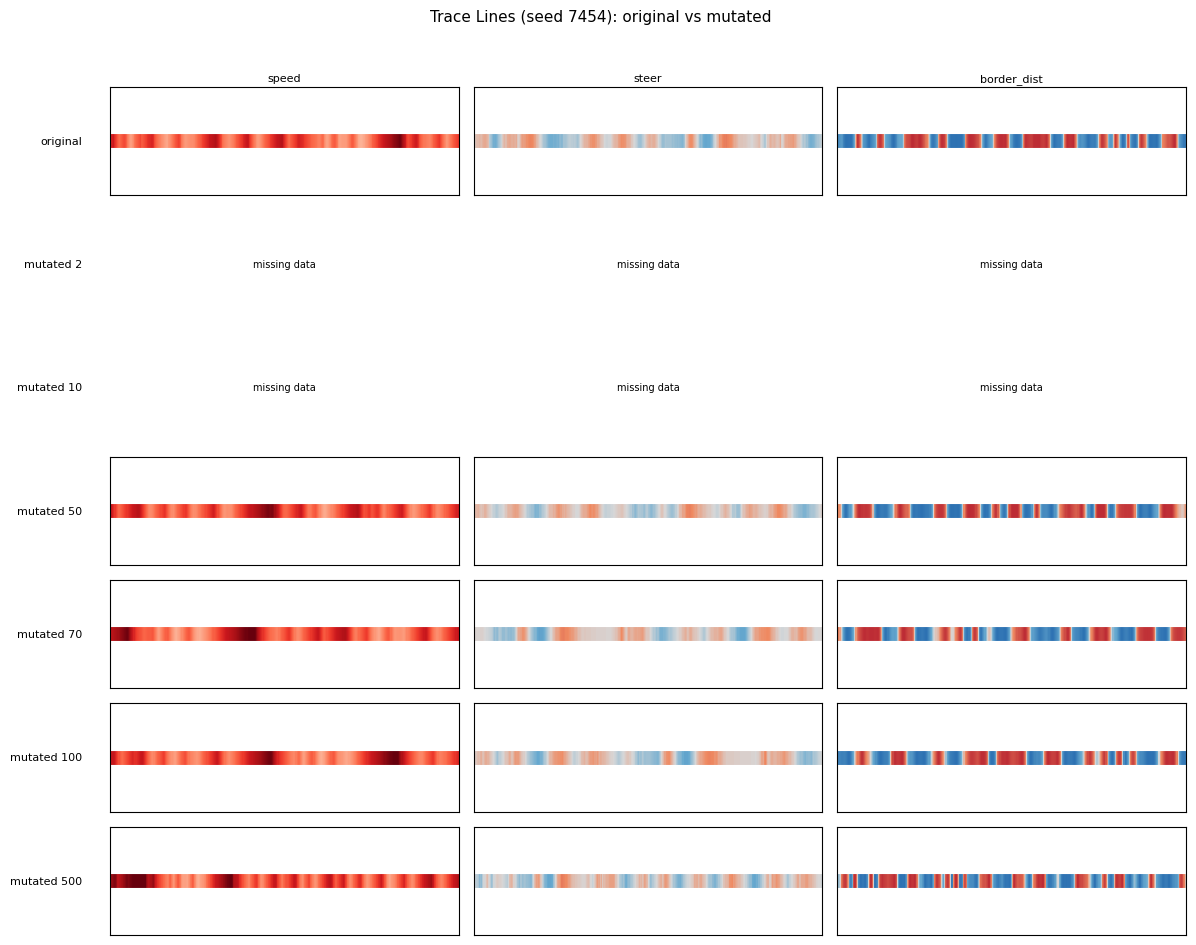

In [47]:
import math
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import mapelite.data_analysis.utils as analysis_utils
importlib.reload(analysis_utils)

from mapelite.data_analysis.utils import (
    plot_track,
    plot_track_heatmap,
    plot_trace_fixed_line,
)

HEATMAP_METRICS = ["speed_trace", "steer_trace", "border_dist_trace"]
HEATMAP_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
    "border_dist_trace": (0, 18),
}

CUSTOM_BURD = LinearSegmentedColormap.from_list(
    "custom_burd",
    [
        (0.0, (33 / 255.0, 102 / 255.0, 172 / 255.0)),
        (0.4, (103 / 255.0, 169 / 255.0, 207 / 255.0)),
        (0.5, (215 / 255.0, 215 / 255.0, 215 / 255.0)),
        (0.6, (239 / 255.0, 138 / 255.0, 98 / 255.0)),
        (1.0, (178 / 255.0, 24 / 255.0, 43 / 255.0)),
    ],
    N=256,
)

HEATMAP_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "brake_trace": "Reds",
    "border_dist_trace": CUSTOM_BURD,
}

LINE_METRICS = ["speed_trace", "steer_trace", "border_dist_trace"]
LINE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "border_dist_trace": (0, 18),
}
LINE_CMAPS = {
    "speed_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "border_dist_trace": CUSTOM_BURD,
}

def _clean_trace(trace):
    if not trace:
        return []
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return []
    values = arr[:, 0]
    distances = arr[:, 1]
    finite = np.isfinite(values) & np.isfinite(distances)
    values, distances = values[finite], distances[finite]
    if len(values) < 2:
        return []
    return list(zip(values.tolist(), distances.tolist()))

def _extract_trace_values(trace):
    if not trace:
        return np.array([])
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 1:
        return np.array([])
    values = arr[:, 0]
    values = values[np.isfinite(values)]
    return values

def _plot_start_point(ax, track):
    if not track:
        return
    start = track[0]
    sx, sy = start.get("x"), start.get("y")
    if sx is None or sy is None:
        return
    ax.scatter(
        [sx],
        [sy],
        s=32,
        c="gold",
        edgecolors="black",
        linewidths=0.6,
        zorder=10,
        marker="o",
    )

for seed, payload in results_by_seed.items():
    intensities = payload["intensities"]
    items = [("original", payload["original_track"], payload["original_traces"])]
    for intensity in intensities:
        items.append(
            (
                f"mutated {intensity}",
                payload["mutated_tracks_by_intensity"].get(intensity),
                payload["mutated_traces_by_intensity"].get(intensity, {}),
            )
        )

    if len(items) == 0:
        print(f"No track data found for seed {seed}. Run Cell 2 first.")
        continue

    # Heatmaps over track geometry
    nrows = len(items)
    ncols = len(HEATMAP_METRICS)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 3.1 * nrows),
        squeeze=False,
    )

    for r, (label, track, traces) in enumerate(items):
        for c, metric in enumerate(HEATMAP_METRICS):
            ax = axes[r, c]
            metric_trace = _clean_trace((traces or {}).get(metric))
            metric_label = metric.replace("_trace", "")

            if track and metric_trace:
                plot_track_heatmap(
                    ax,
                    track,
                    metric_trace,
                    title=metric_label if r == 0 else None,
                    cmap=HEATMAP_CMAPS.get(metric, "Reds"),
                    color_range=HEATMAP_RANGES.get(metric),
                )
                _plot_start_point(ax, track)
            else:
                if track:
                    plot_track(ax, track, title=metric_label if r == 0 else None, track_color="lightgray")
                    _plot_start_point(ax, track)
                else:
                    ax.set_axis_off()
                ax.text(
                    0.5,
                    0.5,
                    "missing data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=8,
                )

            if c == 0:
                ax.set_ylabel(label, fontsize=9)

    fig.suptitle(f"Track Heatmaps (seed {seed}): original vs mutated", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # Linear trace summary
    ncols = len(LINE_METRICS)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 1.2 * nrows + 1.2),
        squeeze=False,
    )

    for r, (label, _track, traces) in enumerate(items):
        for c, metric in enumerate(LINE_METRICS):
            ax = axes[r, c]
            values = _extract_trace_values((traces or {}).get(metric))
            title = metric.replace("_trace", "")
            if values.size >= 2:
                plot_trace_fixed_line(
                    ax,
                    values,
                    line_length=1.0,
                    y=0.0,
                    title=title if r == 0 else None,
                    cmap=LINE_CMAPS.get(metric, "Reds"),
                    color_range=LINE_RANGES.get(metric),
                    linewidth=10,
                    show_colorbar=False,
                )
            else:
                ax.set_axis_off()
                if r == 0:
                    ax.set_title(title, fontsize=8, pad=4)
                ax.text(
                    0.5,
                    0.5,
                    "missing data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=7,
                )

            if c == 0:
                ax.text(
                    -0.08,
                    0.5,
                    label,
                    transform=ax.transAxes,
                    ha="right",
                    va="center",
                    fontsize=8,
                )

    fig.suptitle(f"Trace Lines (seed {seed}): original vs mutated", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()